In [1]:
import os
from collections import namedtuple
from pathlib import Path
from math import ceil

import cbor2
import matplotlib.pyplot as plt

%matplotlib inline

plt.rc('axes', titlesize=10)
plt.rc('axes', labelsize=8)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)
plt.rc('legend', fontsize=8)

# Computation Benchmarks

In [2]:
Result = namedtuple(
    "Result",
    ["group_id", "function_id", "mean", "confidence_lower", "confidence_upper"],
)


def load_result(path: Path) -> Result:
    """Loads a single data point from the given path.
    
    Returns a three tuple, consisting of the lower confidence
    interval, the mean measurement, and the upper confidence interval.
    """
    main_file = path / "benchmark.cbor"
    with open(main_file, "rb") as fobj:
        metadata = cbor2.load(fobj)
    with open(path / metadata["latest_record"], "rb") as fobj:
        data = cbor2.load(fobj)
    return Result(
        group_id=metadata["id"]["group_id"],
        function_id=metadata["id"]["function_id"],
        mean=data["estimates"]["mean"]["point_estimate"],
        confidence_lower=data["estimates"]["mean"]["confidence_interval"]["lower_bound"],
        confidence_upper=data["estimates"]["mean"]["confidence_interval"]["upper_bound"],
    )


def load_results(path: Path) -> list[Result]:
    """Recursively loads all results in the given directory."""
    results = []
    for dirname, _, filenames in os.walk(path):
        if "benchmark.cbor" in filenames:
            results.append(load_result(Path(dirname)))
    return results


def filter_results(results, **attributes):
    return [
        result
        for result in results
        if all(getattr(result, name) == value for name, value in attributes.items())
    ]


def get_result(results, **attributes):
    candidates = filter_results(results, **attributes)
    assert len(candidates) == 1, "ambiguous result filtering"
    return candidates[0]


def get_sizes(results):
    ids = set(result.function_id for result in results)
    sizes = []
    for function_id in ids:
        size = int(function_id.split("-")[0])
        sizes.append(size)
    sizes.sort()
    return sizes


def get_hops(results):
    return get_sizes(results)


def errors(results):
    lower = [result.mean - result.confidence_lower for result in results]
    upper = [result.confidence_upper - result.mean for result in results]
    return (lower, upper)

In [3]:
benchmark_path = Path("./target/criterion/data")
results = load_results(benchmark_path)

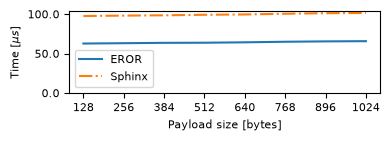

In [4]:
def plot_proc_onion_graph():
    fig, ax = plt.subplots(figsize=(4, 1.5))
    sizes = get_sizes(filter_results(results, group_id="eror/proc_onion"))
    assert sizes == get_sizes(filter_results(results, group_id="sphinx/proc_onion"))
    
    eror_results = [
        get_result(results, group_id="eror/proc_onion", function_id=f"{size}-bytes")
        for size in sizes
    ]
    sphinx_results = [
        get_result(results, group_id="sphinx/proc_onion", function_id=f"{size}-bytes")
        for size in sizes
    ]
    
    ax.plot(
        sizes,
        [er.mean for er in eror_results],
        label="EROR",
    )
    ax.plot(
        sizes,
        [sr.mean for sr in sphinx_results],
        label="Sphinx",
        linestyle="dashdot",
    )

    ax.set_ylabel("Time [${\\mu}s$]")
    ax.set_xlabel("Payload size [bytes]")
    ax.yaxis.set_major_formatter(lambda x, pos: str(x / 1000))
    ax.set_xticks(sizes)
    ax.set_ylim(bottom=0)
    
    ax.legend(loc="lower left")
    fig.tight_layout()
    return fig

plot_proc_onion_graph().savefig("Images/benchmark-proc-onion.pdf", bbox_inches="tight", pad_inches=0.075)

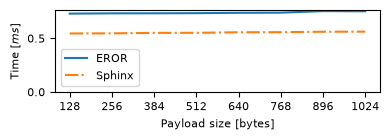

In [5]:
def plot_form_onion_graph():
    fig, ax = plt.subplots(figsize=(4, 1.5))
    sizes = get_sizes(
        result
        for result in results
        if result.group_id == "eror/form_onion" and result.function_id.endswith("bytes")
    )
    
    eror_results = [
        get_result(results, group_id="eror/form_onion", function_id=f"{size}-bytes")
        for size in sizes
    ]
    sphinx_results = [
        get_result(results, group_id="sphinx/form_onion", function_id=f"{size}-bytes")
        for size in sizes
    ]
    
    ax.plot(
        sizes,
        [er.mean for er in eror_results],
        label="EROR",
    )
    ax.plot(
        sizes,
        [sr.mean for sr in sphinx_results],
        label="Sphinx",
        linestyle="dashdot",
    )

    ax.set_ylabel("Time [$ms$]")
    ax.set_xlabel("Payload size [bytes]")
    ax.yaxis.set_major_formatter(lambda x, pos: str(x / 1000000))
    ax.set_xticks(sizes)
    ax.set_ylim(bottom=0)
    
    ax.legend()
    fig.tight_layout()
    return fig

plot_form_onion_graph().savefig("Images/benchmark-form-onion.pdf", bbox_inches="tight", pad_inches=0.075)

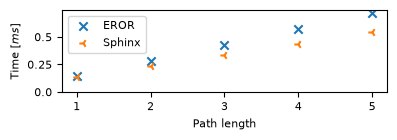

In [6]:
def plot_form_onion_hops_graph():
    fig, ax = plt.subplots(figsize=(4, 1.5))
    hops = get_hops(
        result
        for result in results
        if result.group_id == "eror/form_onion" and result.function_id.endswith("hops")
    )
    
    eror_results = [
        get_result(results, group_id="eror/form_onion", function_id=f"{hop}-hops")
        for hop in hops
    ]
    sphinx_results = [
        get_result(results, group_id="sphinx/form_onion", function_id=f"{hop}-hops")
        for hop in hops
    ]
    
    ax.scatter(
        hops,
        [er.mean for er in eror_results],
        label="EROR",
        marker="x",
    )
    ax.scatter(
        hops,
        [sr.mean for sr in sphinx_results],
        label="Sphinx",
        marker="3",
    )

    ax.set_ylabel("Time [$ms$]")
    ax.set_xlabel("Path length")
    ax.yaxis.set_major_formatter(lambda x, pos: str(x / 1000000))
    ax.set_ylim(bottom=0)
    ax.set_xticks([1, 2, 3, 4, 5])
    
    ax.legend()
    fig.tight_layout()
    return fig

plot_form_onion_hops_graph().savefig("Images/benchmark-form-onion-hops.pdf", bbox_inches="tight", pad_inches=0.075)

# Size Graph

In [7]:
# Explanations for the calculations are in
# Kuhn, Hofheinz, Rupp, Strufe: "Onion Routing with Replies", ASIACRYPT 2021
# Note that we are dealing in whole bytes, so we round bits up to the next multiple of eight.
def to_bytes(bits):
    return int(ceil(bits / 8))

# Note further that their calculations are based on a message m that is part of G, which we
# scale linearly to fit the requested payload_size.
def ue_onion_size(path_length, payload_size):
    # Assumption that a group element in G1 holds 32 bytes (256 bits) of information
    group_elements_needed = int(ceil(payload_size / to_bytes(256)))
    payload_size = group_elements_needed * to_bytes(37376)
    header_size = (2 * path_length - 1) * to_bytes(3968) + to_bytes(3712)
    return header_size + payload_size

def snarg_onion_size(path_length, payload_size):
    header_size = (
        (path_length ** 2) * to_bytes(1024)
        + path_length * to_bytes(3584)
        + (2 * path_length - 1) * to_bytes(1536)
        + to_bytes(1280)
    )
    return payload_size + header_size

## Comparison with Sphinx

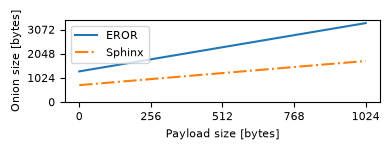

In [8]:
# Sizes taken from examples/onion_sizes.rs
# Path length 5
def plot_size_graph_payload_size():
    payload_sizes = [0, 128, 256, 512, 1024]
    eror_sizes = [1296, 1552, 1808, 2320, 3344]
    sphinx_sizes = [713, 841, 969, 1225, 1737]
    
    fig, ax = plt.subplots(figsize=(4, 1.5))
    
    ax.plot(payload_sizes, eror_sizes, label="EROR")
    ax.plot(payload_sizes, sphinx_sizes, label="Sphinx", linestyle="dashdot")
    
    ax.set_ylabel("Onion size [bytes]")
    ax.set_xlabel("Payload size [bytes]")
    ax.set_xticks([0, 256, 512, 768, 1024])
    ax.set_yticks([0, 1024, 2048, 3072])
    ax.set_ylim(bottom=0)
    
    ax.legend()
    fig.tight_layout()
    return fig

plot_size_graph_payload_size().savefig("Images/packet-sizes.pdf", bbox_inches="tight", pad_inches=0.075)

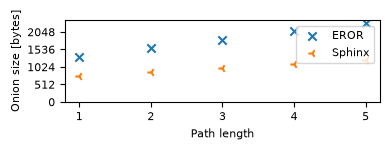

In [9]:
def plot_size_graph_path_length():
    # Values for 512 byte payload
    path_lengths = [1, 2, 3, 4, 5]
    eror_sizes = [1328, 1576, 1824, 2072, 2320]
    sphinx_sizes = [745, 865, 985, 1105, 1225]
    
    fig, ax = plt.subplots(figsize=(4, 1.5))
    
    ax.scatter(path_lengths, eror_sizes, label="EROR", marker="x")
    ax.scatter(path_lengths, sphinx_sizes, label="Sphinx", marker="3")
    
    ax.set_ylabel("Onion size [bytes]")
    ax.set_xlabel("Path length")
    ax.set_xticks(path_lengths)
    ax.set_yticks([0, 512, 1024, 1536, 2048])
    ax.set_ylim(bottom=0)
    
    ax.legend()
    fig.tight_layout()
    return fig

plot_size_graph_path_length().savefig("Images/packet-sizes-path.pdf", bbox_inches="tight", pad_inches=0.075)

## Comparison with Previous Theoretical Schemes

ue_sizes=[4928, 23616, 42304, 79680, 154432]
snarg_sizes=[7328, 7456, 7584, 7840, 8352]


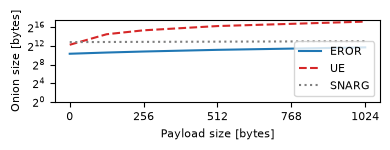

In [10]:
def plot_size_ue_payload_size():
    # Path length: 5
    payload_sizes = [0, 128, 256, 512, 1024]
    eror_sizes = [1296, 1552, 1808, 2320, 3344]
    ue_sizes = [ue_onion_size(5, payload_size) for payload_size in payload_sizes]
    snarg_sizes = [snarg_onion_size(5, payload_size) for payload_size in payload_sizes]

    print(f"{ue_sizes=}")
    print(f"{snarg_sizes=}")

    fig, ax = plt.subplots(figsize=(4, 1.5))
    
    ax.plot(payload_sizes, eror_sizes, label="EROR")
    ax.plot(payload_sizes, ue_sizes, label="UE", color="tab:red", linestyle="dashed")
    ax.plot(payload_sizes, snarg_sizes, label="SNARG", color="tab:gray", linestyle="dotted")
    
    ax.set_ylabel("Onion size [bytes]")
    ax.set_xlabel("Payload size [bytes]")
    ax.set_yscale("log", base=2)
    ax.set_yticks([2**0, 2**4, 2**8, 2**12, 2**16])
    ax.set_xticks([0, 256, 512, 768, 1024])
    ax.set_ylim(bottom=1)
    
    ax.legend()
    fig.tight_layout()
    return fig

plot_size_ue_payload_size().savefig("Images/packet-sizes-ue.pdf", bbox_inches="tight", pad_inches=0.075)

ue_sizes=[75712, 76704, 77696, 78688, 79680]
snarg_sizes=[1440, 2656, 4128, 5856, 7840]


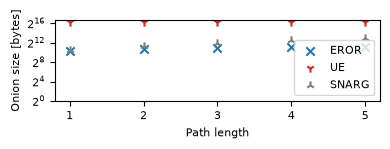

In [11]:
def plot_size_ue_path_length():
    # Values for 512 byte payload
    path_lengths = [1, 2, 3, 4, 5]
    eror_sizes = [1328, 1576, 1824, 2072, 2320]
    ue_sizes = [ue_onion_size(path_length, 512) for path_length in path_lengths]
    snarg_sizes = [snarg_onion_size(path_length, 512) for path_length in path_lengths]
    
    print(f"{ue_sizes=}")
    print(f"{snarg_sizes=}")

    fig, ax = plt.subplots(figsize=(4, 1.5))
    
    ax.scatter(path_lengths, eror_sizes, label="EROR", marker="x")
    ax.scatter(path_lengths, ue_sizes, label="UE", color="tab:red", marker="1")
    ax.scatter(path_lengths, snarg_sizes, label="SNARG", color="tab:gray", marker="2")
    
    ax.set_ylabel("Onion size [bytes]")
    ax.set_xlabel("Path length")
    ax.set_xticks(path_lengths)
    ax.set_yscale("log", base=2)
    ax.set_yticks([2**0, 2**4, 2**8, 2**12, 2**16])
    ax.set_ylim(bottom=1)
    
    ax.legend()
    fig.tight_layout()
    return fig

plot_size_ue_path_length().savefig("Images/packet-sizes-ue-path.pdf", bbox_inches="tight", pad_inches=0.075)

In [12]:
# Compute the break-even point between EROR and SNARG
# Path Length: 5
def breakeven_eror_snarg():
    payload_size = 0
    while True:
        eror_size = 1296 + 2 * payload_size
        snarg_size = snarg_onion_size(5, payload_size)
        if snarg_size < eror_size:
            print(f"SNARG is better than EROR at {payload_size} bytes of payload")
            break
        payload_size += 1
    
breakeven_eror_snarg()

SNARG is better than EROR at 6033 bytes of payload
